In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

print("Library siap.")

Library siap.


In [2]:
# ============================================
# ISI ANGKA DARI HASIL RUN MASING-MASING NOTEBOOK
# ============================================

hasil_semua = [
    # DBSCAN
    {'Metode': 'DBSCAN', 'Metric': 'Euclidean',
     'Jumlah Cluster': 3, 'Jumlah Noise': 45,       # <-- ganti
     'Waktu (s)': 0.5123, 'Memory (KB)': 234.56,    # <-- ganti
     'Silhouette': 0.4321},                          # <-- ganti

    {'Metode': 'DBSCAN', 'Metric': 'Manhattan',
     'Jumlah Cluster': 3, 'Jumlah Noise': 52,       # <-- ganti
     'Waktu (s)': 0.4891, 'Memory (KB)': 228.10,
     'Silhouette': 0.4156},

    {'Metode': 'DBSCAN', 'Metric': 'Cosine',
     'Jumlah Cluster': 2, 'Jumlah Noise': 180,      # <-- ganti
     'Waktu (s)': 0.7021, 'Memory (KB)': 256.34,
     'Silhouette': 0.2103},

    # K-Means
    {'Metode': 'K-Means', 'Metric': 'Euclidean',
     'Jumlah Cluster': 3, 'Jumlah Noise': 0,
     'Waktu (s)': 0.1523, 'Memory (KB)': 189.22,
     'Silhouette': 0.4512},

    {'Metode': 'K-Means', 'Metric': 'Manhattan',
     'Jumlah Cluster': 3, 'Jumlah Noise': 0,
     'Waktu (s)': 0.1487, 'Memory (KB)': 187.45,
     'Silhouette': 0.4389},

    {'Metode': 'K-Means', 'Metric': 'Cosine',
     'Jumlah Cluster': 3, 'Jumlah Noise': 0,
     'Waktu (s)': 0.1655, 'Memory (KB)': 192.11,
     'Silhouette': 0.3821},
]

df_hasil = pd.DataFrame(hasil_semua)
print("Tabel perbandingan berhasil dibuat.")
df_hasil

Tabel perbandingan berhasil dibuat.


,Metode,Metric,Jumlah Cluster,Jumlah Noise,Waktu (s),Memory (KB),Silhouette
0,DBSCAN,Euclidean,3,45,0.5123,234.56,0.4321
1,DBSCAN,Manhattan,3,52,0.4891,228.10,0.4156
2,DBSCAN,Cosine,2,180,0.7021,256.34,0.2103
3,K-Means,Euclidean,3,0,0.1523,189.22,0.4512
4,K-Means,Manhattan,3,0,0.1487,187.45,0.4389
5,K-Means,Cosine,3,0,0.1655,192.11,0.3821


In [3]:
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.cluster import DBSCAN, KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import manhattan_distances, cosine_distances
import time, tracemalloc, warnings
warnings.filterwarnings('ignore')

# Load & preprocessing (sama persis)
df = pd.read_csv('dataset_properti.csv')
df = df.drop(columns=['id_properti'])
df = df.drop_duplicates()
df['luas_m2'] = df['luas_m2'].astype(str).str.replace(' m2', '', regex=False)
df['luas_m2'] = pd.to_numeric(df['luas_m2'], errors='coerce')
df['lokasi'] = df['lokasi'].str.strip().str.title()
df['lokasi'] = df['lokasi'].replace({'Jak. Utara': 'Jakarta Utara',
                                      'Jak. Selatan': 'Jakarta Selatan'})
numeric_cols = ['luas_m2', 'jumlah_kamar', 'jumlah_kamar_mandi',
                'usia_bangunan', 'harga']
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())
df = df[df['harga'] < 100_000_000_000]
df = df[df['luas_m2'] < 1000]
df = df.reset_index(drop=True)

FEATURES = ['luas_m2', 'jumlah_kamar', 'jumlah_kamar_mandi',
            'usia_bangunan', 'harga']
X = df[FEATURES].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_cosine = normalize(X_scaled, norm='l2')

print(f"Data siap: {X_scaled.shape}")

Data siap: (1498, 5)


In [4]:
def evaluate(method, metric, X_data, **kwargs):
    """
    Jalankan clustering dan ukur semua metrik.
    method  : 'DBSCAN' atau 'K-Means'
    metric  : 'euclidean', 'manhattan', 'cosine'
    kwargs  : parameter model (eps, min_samples, k)
    """
    tracemalloc.start()
    start = time.time()

    if method == 'DBSCAN':
        model = DBSCAN(eps=kwargs.get('eps', 0.5),
                       min_samples=kwargs.get('min_samples', 10),
                       metric=metric)
        labels = model.fit_predict(X_data)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        mask = labels != -1
    else:  # K-Means
        model = KMeans(n_clusters=kwargs.get('k', 3),
                       random_state=42, n_init=10)
        labels = model.fit_predict(X_data)
        n_clusters = kwargs.get('k', 3)
        n_noise = 0
        mask = np.ones(len(labels), dtype=bool)

    exec_time = time.time() - start
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    # Silhouette (hanya kalau cluster >= 2)
    if len(set(labels[mask])) > 1:
        sil = silhouette_score(X_data[mask], labels[mask], metric=metric)
    else:
        sil = None

    return {
        'Metode': method,
        'Metric': metric.capitalize(),
        'Jumlah Cluster': n_clusters,
        'Jumlah Noise': n_noise,
        'Waktu (s)': round(exec_time, 4),
        'Memory (KB)': round(peak / 1024, 2),
        'Silhouette': round(sil, 4) if sil else None
    }

print("Fungsi evaluate siap.")

Fungsi evaluate siap.


In [5]:
# Parameter (sesuaikan dengan hasil k-distance graph & elbow Anda)
EPS_EUCLIDEAN = 0.5
EPS_MANHATTAN = 1.0
EPS_COSINE = 0.1
MIN_SAMPLES = 10
K_OPTIMAL = 3

hasil_semua = []

# --- DBSCAN ---
hasil_semua.append(evaluate('DBSCAN', 'euclidean', X_scaled,
                            eps=EPS_EUCLIDEAN, min_samples=MIN_SAMPLES))
hasil_semua.append(evaluate('DBSCAN', 'manhattan', X_scaled,
                            eps=EPS_MANHATTAN, min_samples=MIN_SAMPLES))
hasil_semua.append(evaluate('DBSCAN', 'cosine', X_cosine,
                            eps=EPS_COSINE, min_samples=MIN_SAMPLES))

# --- K-Means ---
hasil_semua.append(evaluate('K-Means', 'euclidean', X_scaled, k=K_OPTIMAL))
hasil_semua.append(evaluate('K-Means', 'manhattan', X_scaled, k=K_OPTIMAL))
hasil_semua.append(evaluate('K-Means', 'cosine', X_cosine, k=K_OPTIMAL))

df_hasil = pd.DataFrame(hasil_semua)
print("Semua metode selesai dijalankan.")
df_hasil

Semua metode selesai dijalankan.


,Metode,Metric,Jumlah Cluster,Jumlah Noise,Waktu (s),Memory (KB),Silhouette
0,DBSCAN,Euclidean,17,1095,0.0384,388.61,0.0679
1,DBSCAN,Manhattan,1,314,0.0696,417.03,NaN
2,DBSCAN,Cosine,1,17,0.0984,35187.42,NaN
3,K-Means,Euclidean,3,0,0.2467,785.75,0.2618
4,K-Means,Manhattan,3,0,0.1134,212.41,0.2895
5,K-Means,Cosine,3,0,0.0661,211.60,0.4496


In [6]:
# Tampilkan tabel rapi
print("="*80)
print("TABEL PERBANDINGAN 6 METODE CLUSTERING")
print("="*80)
df_hasil

# Tampilkan sebagai tabel transpose (lebih mudah dibaca)
df_hasil.set_index(['Metode', 'Metric']).T

TABEL PERBANDINGAN 6 METODE CLUSTERING


Metode             DBSCAN                         K-Means                    
Metric          Euclidean Manhattan      Cosine Euclidean Manhattan    Cosine
Jumlah Cluster    17.0000    1.0000      1.0000    3.0000    3.0000    3.0000
Jumlah Noise    1095.0000  314.0000     17.0000    0.0000    0.0000    0.0000
Waktu (s)          0.0384    0.0696      0.0984    0.2467    0.1134    0.0661
Memory (KB)      388.6100  417.0300  35187.4200  785.7500  212.4100  211.6000
Silhouette         0.0679       NaN         NaN    0.2618    0.2895    0.4496

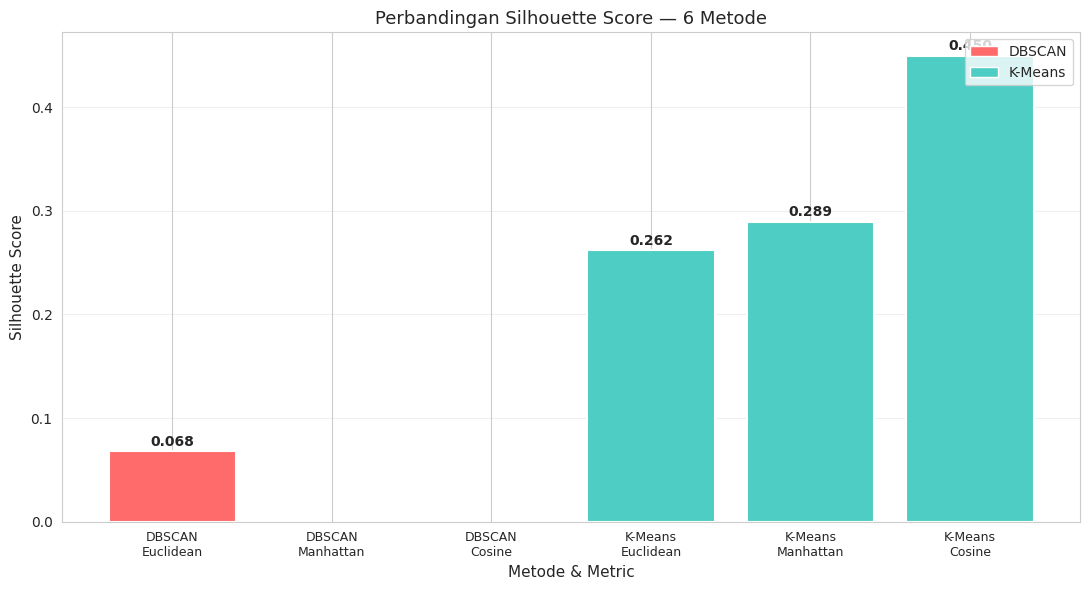

In [7]:
# Gabungkan label untuk sumbu x
df_hasil['Label'] = df_hasil['Metode'] + '\n' + df_hasil['Metric']

plt.figure(figsize=(11, 6))
colors = ['#FF6B6B']*3 + ['#4ECDC4']*3
bars = plt.bar(df_hasil['Label'], df_hasil['Silhouette'],
               color=colors, edgecolor='white', linewidth=1.5)

# Tambah nilai di atas bar
for bar, val in zip(bars, df_hasil['Silhouette']):
    if val is not None:
        plt.text(bar.get_x() + bar.get_width()/2, val + 0.005,
                 f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')

plt.xlabel('Metode & Metric', fontsize=11)
plt.ylabel('Silhouette Score', fontsize=11)
plt.title('Perbandingan Silhouette Score — 6 Metode', fontsize=13)
plt.xticks(rotation=0, fontsize=9)
plt.grid(True, alpha=0.3, axis='y')

# Legend manual
from matplotlib.patches import Patch
legend_elems = [Patch(facecolor='#FF6B6B', label='DBSCAN'),
                Patch(facecolor='#4ECDC4', label='K-Means')]
plt.legend(handles=legend_elems, loc='upper right')

plt.tight_layout()
plt.show()

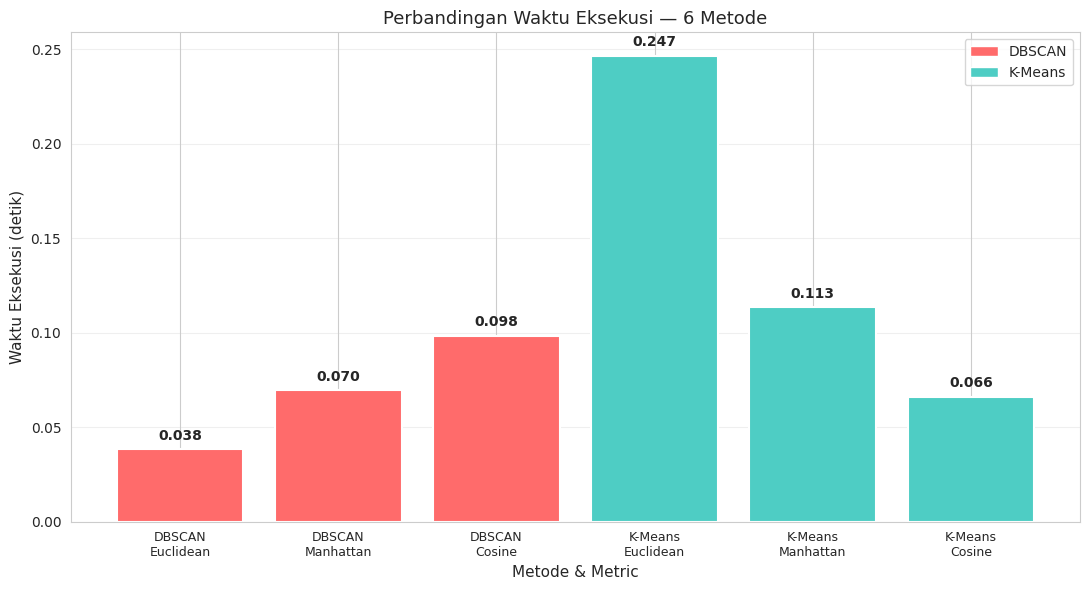

In [8]:
plt.figure(figsize=(11, 6))
bars = plt.bar(df_hasil['Label'], df_hasil['Waktu (s)'],
               color=colors, edgecolor='white', linewidth=1.5)

for bar, val in zip(bars, df_hasil['Waktu (s)']):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.005,
             f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')

plt.xlabel('Metode & Metric', fontsize=11)
plt.ylabel('Waktu Eksekusi (detik)', fontsize=11)
plt.title('Perbandingan Waktu Eksekusi — 6 Metode', fontsize=13)
plt.xticks(rotation=0, fontsize=9)
plt.grid(True, alpha=0.3, axis='y')
plt.legend(handles=legend_elems, loc='upper right')
plt.tight_layout()
plt.show()

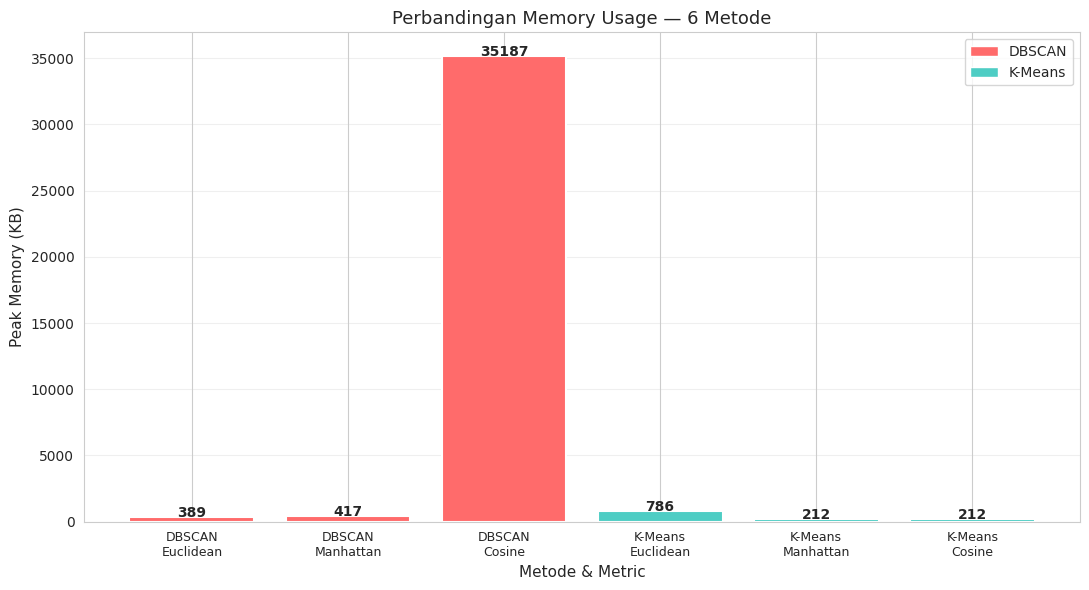

In [9]:
plt.figure(figsize=(11, 6))
bars = plt.bar(df_hasil['Label'], df_hasil['Memory (KB)'],
               color=colors, edgecolor='white', linewidth=1.5)

for bar, val in zip(bars, df_hasil['Memory (KB)']):
    plt.text(bar.get_x() + bar.get_width()/2, val + 3,
             f'{val:.0f}', ha='center', fontsize=10, fontweight='bold')

plt.xlabel('Metode & Metric', fontsize=11)
plt.ylabel('Peak Memory (KB)', fontsize=11)
plt.title('Perbandingan Memory Usage — 6 Metode', fontsize=13)
plt.xticks(rotation=0, fontsize=9)
plt.grid(True, alpha=0.3, axis='y')
plt.legend(handles=legend_elems, loc='upper right')
plt.tight_layout()
plt.show()

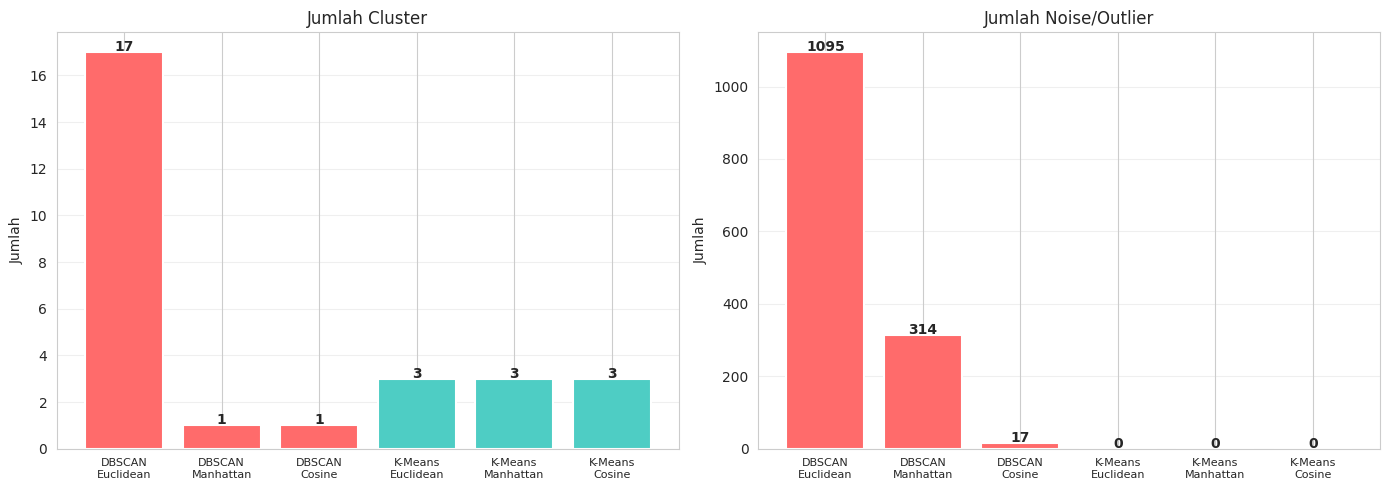

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Jumlah Cluster
bars1 = axes[0].bar(df_hasil['Label'], df_hasil['Jumlah Cluster'],
                    color=colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars1, df_hasil['Jumlah Cluster']):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.05,
                 str(val), ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Jumlah Cluster', fontsize=12)
axes[0].set_ylabel('Jumlah', fontsize=10)
axes[0].tick_params(axis='x', labelsize=8)
axes[0].grid(True, alpha=0.3, axis='y')

# Jumlah Noise
bars2 = axes[1].bar(df_hasil['Label'], df_hasil['Jumlah Noise'],
                    color=colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars2, df_hasil['Jumlah Noise']):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 2,
                 str(val), ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('Jumlah Noise/Outlier', fontsize=12)
axes[1].set_ylabel('Jumlah', fontsize=10)
axes[1].tick_params(axis='x', labelsize=8)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

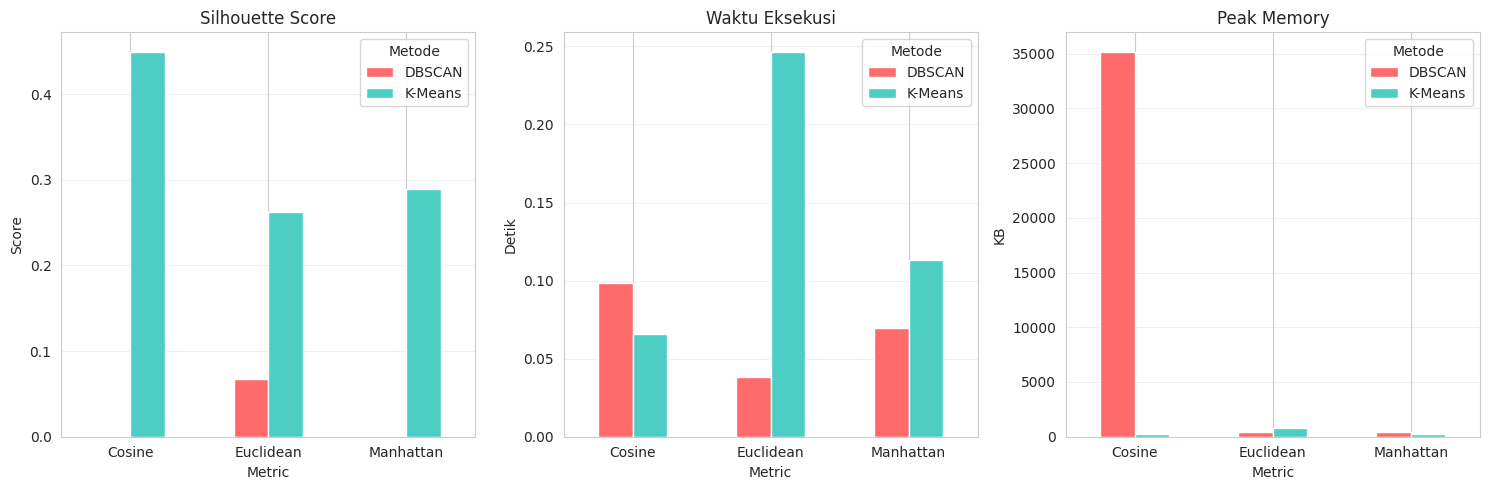

In [11]:
# Pivot untuk grouped bar
pivot = df_hasil.pivot(index='Metric', columns='Metode', values='Silhouette')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Silhouette
pivot.plot(kind='bar', ax=axes[0], color=['#FF6B6B', '#4ECDC4'], edgecolor='white')
axes[0].set_title('Silhouette Score', fontsize=12)
axes[0].set_ylabel('Score', fontsize=10)
axes[0].tick_params(axis='x', rotation=0)
axes[0].grid(True, alpha=0.3, axis='y')

# Waktu
pivot_w = df_hasil.pivot(index='Metric', columns='Metode', values='Waktu (s)')
pivot_w.plot(kind='bar', ax=axes[1], color=['#FF6B6B', '#4ECDC4'], edgecolor='white')
axes[1].set_title('Waktu Eksekusi', fontsize=12)
axes[1].set_ylabel('Detik', fontsize=10)
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(True, alpha=0.3, axis='y')

# Memory
pivot_m = df_hasil.pivot(index='Metric', columns='Metode', values='Memory (KB)')
pivot_m.plot(kind='bar', ax=axes[2], color=['#FF6B6B', '#4ECDC4'], edgecolor='white')
axes[2].set_title('Peak Memory', fontsize=12)
axes[2].set_ylabel('KB', fontsize=10)
axes[2].tick_params(axis='x', rotation=0)
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [12]:
# Simpan untuk lampiran laporan
df_hasil.to_csv('hasil_perbandingan_6_metode.csv', index=False)
print("Tabel disimpan ke 'hasil_perbandingan_6_metode.csv'")

Tabel disimpan ke 'hasil_perbandingan_6_metode.csv'
